<a href="https://colab.research.google.com/github/HosseinMasoudi/Sentiment_Analysis_with_Transformers/blob/master/SentimentAnalysisTransformersNLP(WithOutHazm)(Use_Model_in_MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [2]:
!pip install num2fawords
!pip install parsivar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 20.4 MB/s eta 0:00:00


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import tensorflow as tf
import transformers
import JackageNormalizer
import json

from parsivar import Tokenizer
from JackageNormalizer import normalize_persian_text

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

from tensorflow.keras import layers, Model ,Input
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("float32")

from tensorflow.keras import regularizers
from tensorflow import keras

from transformers import pipeline
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, AutoConfig, TFBertModel
from transformers import DataCollatorWithPadding
from transformers import DistilBertTokenizerFast
from transformers import TFDistilBertForSequenceClassification
from transformers import TFAutoModel

from google.colab import drive, files

import tqdm as notebook_tqdm

In [6]:
model_name = "HooshvareLab/bert-fa-base-uncased"

testing the pip line...

In [22]:
# Use a pipeline as a high-level helper
pipe = pipeline("text-classification", model=model_name)
# Example usage of the pipeline
result = pipe("این غذا خیلی خوشمزه بود!")
print(result)

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


[{'label': 'LABEL_0', 'score': 0.6025859713554382}]


### 1. Load and Inspect Your Dataset

In [7]:
df = pd.read_csv("/content/cleaned_snappfood copy.csv")
df.head()

,comment,label,comment_length,comment_cleaned
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,0,47,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...,1,132,قرار بود ساعته برسه ولی نیم ساعت زودتر از موق...
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...,0,89,قیمت این مدل اصلا با کیفیتش سازگاری نداره فقط ...
3,عالی بود همه چه درست و به اندازه و کیفیت خوب، ...,1,99,عالی بود همه چه درست و به اندازه و کیفیت خوب ا...
4,شیرینی وانیلی فقط یک مدل بود.,1,29,شیرینی وانیلی فقط یک مدل بود


In [8]:
df.info()
df.isnull().count()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65973 entries, 0 to 65972
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   comment          65973 non-null  object
 1   label            65973 non-null  int64 
 2   comment_length   65973 non-null  int64 
 3   comment_cleaned  65973 non-null  object
dtypes: int64(2), object(2)
memory usage: 2.0+ MB


,0
comment,65973
label,65973
comment_length,65973
comment_cleaned,65973


In [9]:
print(df.shape)
print(df.columns)

(65973, 4)
Index(['comment', 'label', 'comment_length', 'comment_cleaned'], dtype='object')


In [10]:
df = df[['comment', 'label']]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
tokenizer = Tokenizer()

def clean_text(text):
    text = normalize_persian_text(text)
    tokens = tokenizer.tokenize_words(text)
    return ' '.join(tokens)


In [12]:
df['comment'] = df['comment'].apply(clean_text)

df['comment'].sample(20)

,comment
52711,ته چین لوبیا عالی
48493,شیرینی اشتباه آوردن
48096,سالاد سزار افتضاح
57557,خوب طعم لیمو امانی خیلی ترشش بود
2262,سلام عرض ادب بنده مشتری پای ثابت اسنپ فود سوپر...
1896,حجم شله زرد نسبت قیمت خیلی کم بود متاسفانه بام...
20748,عالی بهداشتی قیمت مناسبی
24253,دستتون درد نکنه عالی گرم
64309,پنیر گودا ساندویچها نبود دفعه قبل موجود
2006,طعم عالیای


#### Split into train / val / test

In [13]:
texts = df['comment'].tolist()
labels = df['label'].values

In [14]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

70% → train

15% → validation

15% → test

In [15]:
classes = np.unique(train_labels)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Class weights:", class_weight)

Class weights: {0: 1.0218844043193485, 1: 0.9790332838668645}


In [16]:
print(f"Train shape: {len(train_texts)}, Validation shape: {len(val_texts)}, Test shape: {len(test_texts)}\n")

print("Data loaded and processed successfully.")
print(f"Sample of cleaned text:\n ({train_texts[0]}) \n label: {train_labels[0]}")

Train shape: 46181, Validation shape: 9896, Test shape: 9896

Data loaded and processed successfully.
Sample of cleaned text:
 (سیبزمینی روغن مونده درست بو میداد قابل خوردن شکل شمایلش خوب نبود) 
 label: 0


### 2. Prepare Text and Tokenize

In [17]:
model_tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [18]:
def encode_texts(texts):
    return model_tokenizer(list(texts), truncation=True, padding=True, max_length=128)

In [19]:
train_encoded = encode_texts(train_texts)
val_encoded = encode_texts(val_texts)
test_encoded = encode_texts(test_texts)

convert Encoding to TF DataSet

In [20]:
def make_tf_dataset(encoding, labels, shuffle=False, BATCH_SIZE=16):
    encoding = {"input_ids": encoding["input_ids"], "attention_mask": encoding["attention_mask"]}
    dataset = tf.data.Dataset.from_tensor_slices((encoding, labels))
    if shuffle:
        dataset = dataset.shuffle(1000)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [21]:
train_dataset = make_tf_dataset(train_encoded, train_labels, shuffle=True)
val_dataset = make_tf_dataset(val_encoded, val_labels)
test_dataset = make_tf_dataset(test_encoded, test_labels)

In [23]:
for batch_x, batch_y in train_dataset.take(1):
    print("Batch X keys:", batch_x.keys())
    print("input_ids shape:", batch_x["input_ids"].shape)
    print("attention_mask shape:", batch_x["attention_mask"].shape)
    print("Labels shape:", batch_y.shape)
    print("Labels:", batch_y.numpy())

Batch X keys: dict_keys(['input_ids', 'attention_mask'])
input_ids shape: (16, 79)
attention_mask shape: (16, 79)
Labels shape: (16,)
Labels: [1 0 1 1 1 0 0 0 0 1 0 1 1 0 1 0]


In [24]:
sample_ids = batch_x["input_ids"][0].numpy()
decoded_text = model_tokenizer.decode(sample_ids, skip_special_tokens=True)
print("Decoded text:", decoded_text)
print("Label:", batch_y[0].numpy())

Decoded text: عالی وبسیار تازه مرسی
Label: 1


### 3. Laod the Model_Compile the Model_Train the Model

Model architecture:
1. Inputs (all from tf.keras)
2. Transformer backbone (freeze the backbone completely)
3. Extract sentence representation (choose one option)
4. Head (MLP classifier)

In [25]:
def build_sentiment_model(model_name: str):

    input_ids      = Input(shape=(None,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(None,), dtype=tf.int32, name="attention_mask")

    transformer = TFAutoModel.from_pretrained(model_name)
    transformer.trainable = False

    outputs = transformer(input_ids=input_ids, attention_mask=attention_mask)
    cls = outputs.pooler_output

    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-5), name="Dense")(cls)
    x = layers.Dropout(0.3, name="Dropout")(x)
    logits = layers.Dense(1, activation="sigmoid", dtype="float16", name="OutputSigmoid")(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=logits)
    return model

model = build_sentiment_model(model_name)

model.summary()

tf_model.h5:   0%|          | 0.00/963M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at HooshvareLab/bert-fa-base-uncased were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at HooshvareLab/bert-fa-base-uncased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for pred

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1628413   ['input_ids[0][0]',           
 )                           ngAndCrossAttentions(last_   44         'attention_mask[0][0]']      
                             hidden_state=(None, None,                                        

### Stage 2: unfreeze last 2 encoder layers + small LR

In [27]:
backbone = next((lyr for lyr in model.layers if hasattr(lyr, "bert")), None)
if backbone is not None:
    backbone.trainable = True
    try:
        enc_layers = backbone.bert.encoder.layer
        n = len(enc_layers)
        for i, enc in enumerate(enc_layers):
            enc.trainable = (i >= n-2)
        print("Unfroze last 2 encoder layers.")
    except Exception as e:
        print("WARN: per-layer flag failed, unfreezing whole backbone.", e)
        backbone.trainable = True
else:
    print("WARN: backbone not found – training head only.")


Unfroze last 2 encoder layers.


In [28]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1628413   ['input_ids[0][0]',           
 )                           ngAndCrossAttentions(last_   44         'attention_mask[0][0]']      
                             hidden_state=(None, None,                                        

compile

In [29]:
optimizer_adamW_stage2 = tf.keras.optimizers.AdamW(learning_rate=5e-6, weight_decay=0.01, clipnorm=1.0)

model.compile(
    optimizer=optimizer_adamW_stage2,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

CallBack

In [30]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_model_weights(stage2).h5",
        monitor="val_loss",
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6
    ),
]

Fit

In [31]:
history_2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=7,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/7
2887/2887 [==============================] - ETA: 0s - loss: 0.4207 - accuracy: 0.8098 - auc: 0.8835 - precision: 0.8528 - recall: 0.7585

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


2887/2887 [==============================] - 561s 180ms/step - loss: 0.4207 - accuracy: 0.8098 - auc: 0.8835 - precision: 0.8528 - recall: 0.7585 - val_loss: 0.3487 - val_accuracy: 0.8526 - val_auc: 0.9238 - val_precision: 0.8752 - val_recall: 0.8296 - lr: 5.0000e-06
Epoch 2/7
2887/2887 [==============================] - 450s 156ms/step - loss: 0.3544 - accuracy: 0.8485 - auc: 0.9191 - precision: 0.8918 - recall: 0.8005 - val_loss: 0.3321 - val_accuracy: 0.8619 - val_auc: 0.9315 - val_precision: 0.8989 - val_recall: 0.8219 - lr: 5.0000e-06
Epoch 3/7
2887/2887 [==============================] - 476s 165ms/step - loss: 0.3318 - accuracy: 0.8601 - auc: 0.9298 - precision: 0.9022 - recall: 0.8143 - val_loss: 0.3263 - val_accuracy: 0.8668 - val_auc: 0.9346 - val_precision: 0.9175 - val_recall: 0.8122 - lr: 5.0000e-06
Epoch 4/7
2887/2887 [==============================] - 462s 160ms/step - loss: 0.3173 - accuracy: 0.8678 - auc: 0.9357 - precision: 0.9076 - recall: 0.8251 - val_loss: 0.3196 -

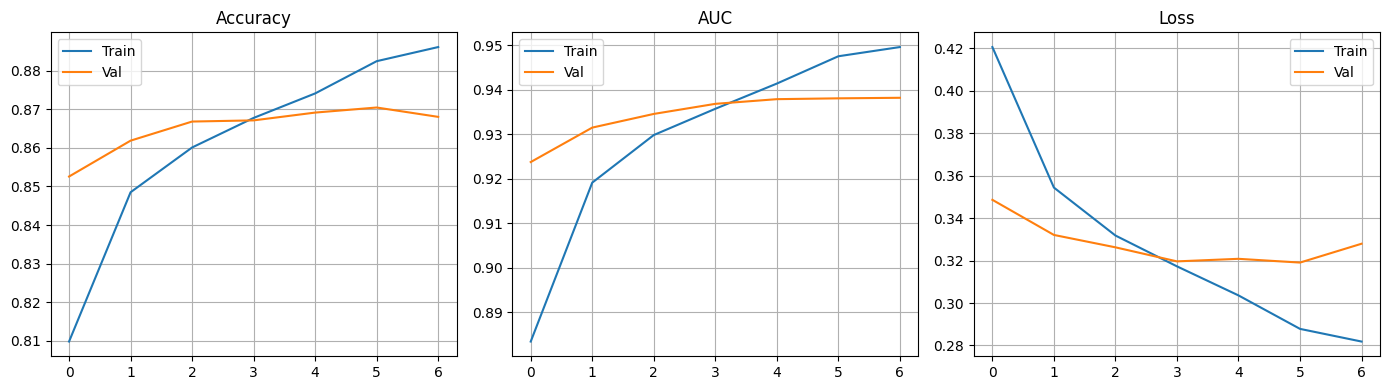

In [32]:
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(history_2.history['auc'], label='Train')
plt.plot(history_2.history['val_auc'], label='Val')
plt.title('AUC')
plt.legend()
plt.grid(True)

plt.subplot(1,3,3)
plt.plot(history_2.history['loss'], label='Train')
plt.plot(history_2.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

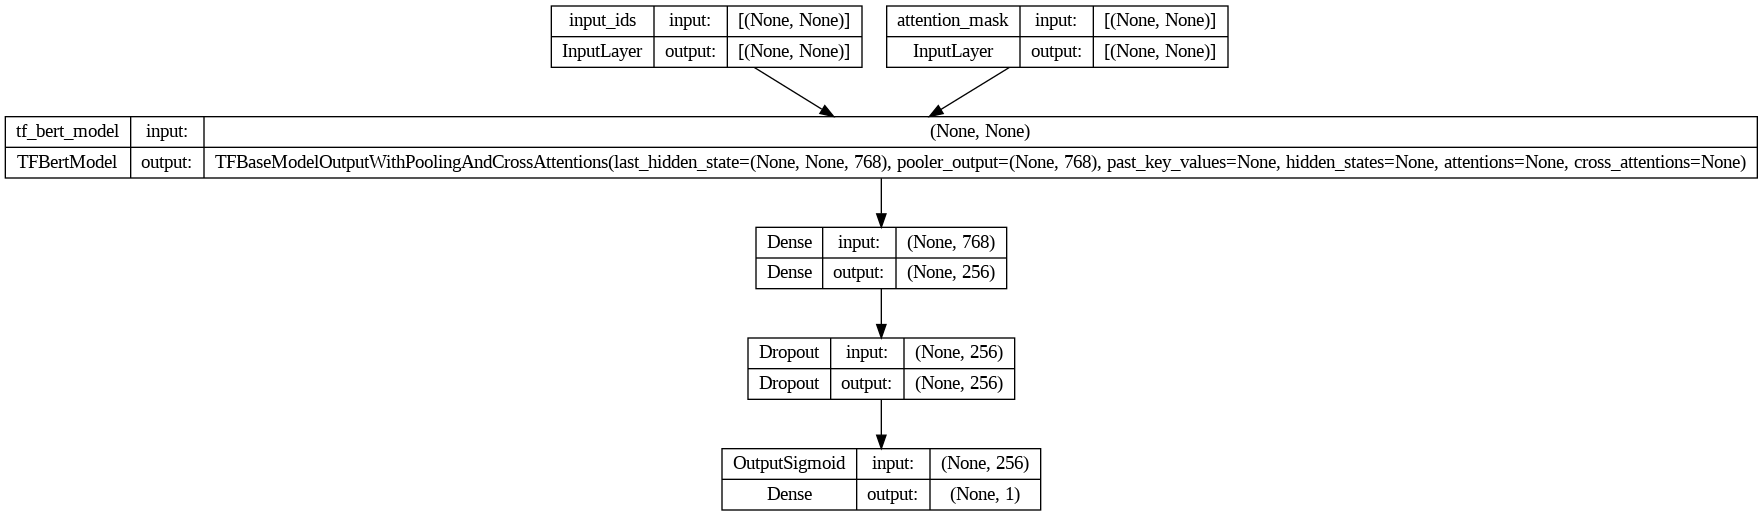

In [58]:
keras.utils.plot_model(model, to_file='MyModel.png',show_shapes=True)

### 4. Evaluate on TEST set

In [33]:
print("Final Evaluation on Test Set\n")
metrics = model.evaluate(test_dataset, return_dict=True, verbose=1)
print(metrics)

print("Loss:", metrics["loss"])
print("Accuracy:", metrics["accuracy"])
print("AUC:", metrics["auc"])
print("Precision:", metrics["precision"])
print("Recall:", metrics["recall"])

Final Evaluation on Test Set

619/619 [==============================] - 33s 48ms/step - loss: 0.3384 - accuracy: 0.8628 - auc: 0.9312 - precision: 0.8951 - recall: 0.8272
{'loss': 0.33842572569847107, 'accuracy': 0.8627728223800659, 'auc': 0.9311798214912415, 'precision': 0.895143985748291, 'recall': 0.8272438645362854}
Loss: 0.33842572569847107
Accuracy: 0.8627728223800659
AUC: 0.9311798214912415
Precision: 0.895143985748291
Recall: 0.8272438645362854


### 5. Save the Fine-Tuned Model

Save model's architecture

In [34]:
model_config = model.get_config()

with open('model_config.json', 'w') as f:
  json.dump(model_config, f, indent=4)

Save model's architecture and weights

In [ ]:
model.save("saved_model_tf.h5", save_format="tf", include_optimizer=False)


In [36]:
model.save('model.h5')

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [37]:
model.save('model.keras')

/usr/local/lib/python3.12/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


Save model Tokenizer

In [38]:
model_tokenizer.save_pretrained("./model_tokenizer")

('./model_tokenizer/tokenizer_config.json',
 './model_tokenizer/special_tokens_map.json',
 './model_tokenizer/vocab.txt',
 './model_tokenizer/added_tokens.json',
 './model_tokenizer/tokenizer.json')

In [39]:
!mkdir -p sentiment_model

save weights (in drive)

In [60]:
model.save_weights("/content/drive/MyDrive/sentiment_model/weights.h5")

In [ ]:
model.save_weights("weight.h5")


connect to google Drive

In [40]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
!zip -r sentiment_model.zip sentiment_model

  adding: sentiment_model/ (stored 0%)
  adding: sentiment_model/model.h5 (deflated 43%)
  adding: sentiment_model/model_tokenizer/ (stored 0%)
  adding: sentiment_model/model_tokenizer/vocab.txt (deflated 62%)
  adding: sentiment_model/model_tokenizer/special_tokens_map.json (deflated 42%)
  adding: sentiment_model/model_tokenizer/tokenizer.json (deflated 72%)
  adding: sentiment_model/model_tokenizer/tokenizer_config.json (deflated 74%)
  adding: sentiment_model/model.keras (deflated 54%)
  adding: sentiment_model/best_model_weights(stage2).h5 (deflated 43%)
  adding: sentiment_model/model_config.json (deflated 84%)


In [47]:
!cp /content/sentiment_model.zip /content/drive/MyDrive/sentiment_model_zip

testing loading model

In [66]:
model.save("saved_model_tf.h5", save_format="tf", include_optimizer=False)

In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/saved_model_tf.h5", custom_objects={"TFBertModel": TFBertModel})

In [ ]:
from transformers import TFBertModel, AutoTokenizer
from tensorflow import keras
import numpy as np

m = keras.models.load_model("saved_model_tf", custom_objects={"TFBertModel": TFBertModel})
m.summary()

batch = model_tokenizer(["این فیلم عالی بود!", "افتضاح بود!"], padding=True, truncation=True, max_length=64, return_tensors="np")
pred = m.predict({"input_ids": batch["input_ids"], "attention_mask": batch["attention_mask"]}, verbose=0)
print(pred.reshape(-1))
